## 4.1 LLM 구조 구현하기

In [1]:
# GPT-2
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # 어휘사전 크기
    "context_length": 1024,  # 문맥 길이
    "emb_dim": 768,          # 임베딩 차원
    "n_heads": 12,           # 어텐션 헤드 개수
    "n_layers": 12,          # 층 개수
    "drop_rate": 0.1,        # 드롭아웃 비율
    "qkv_bias": False        # 쿼리, 키, 값 계산을 위한 편향
}

In [2]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 더미 클래스

    def forward(self, x):
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # 층 정규화 인터페이스를 흉내내기 위한 매개변수

    def forward(self, x):
        return x

In [3]:
# 토큰화 예시
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("출력 크기:", logits.shape)
print(logits)

출력 크기: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2 층 정규화로 활성화 정규화하기

In [5]:
torch.manual_seed(123)

batch_example = torch.randn(2, 5)

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [6]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("평균:\n", mean)
print("분산:\n", var)

평균:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
분산:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [7]:
out_norm = (out - mean) / torch.sqrt(var)
print("정규화된 층 출력:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("평균:\n", mean)
print("분산:\n", var)

정규화된 층 출력:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
평균:
 tensor([[9.9341e-09],
        [5.9605e-08]], grad_fn=<MeanBackward1>)
분산:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [8]:
torch.set_printoptions(sci_mode=False)
print("평균:\n", mean)
print("분산:\n", var)

평균:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
분산:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        # trainable parameter
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False) # correction=0
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [10]:
# LayerNorm 테스트
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

In [11]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("평균:\n", mean)
print("분산:\n", var)


평균:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
분산:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## 4.3 GELU 활성화 함수를 사용하는 피드 포워드 네트워크 구현하기

GELU(Gaussian Error Linear Uint)
- GELU(x) = x⋅𝛷(x)
- ReLU보다 더 복잡하고 부드러워 딥러닝 모델 성능을 향상시킴

In [12]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

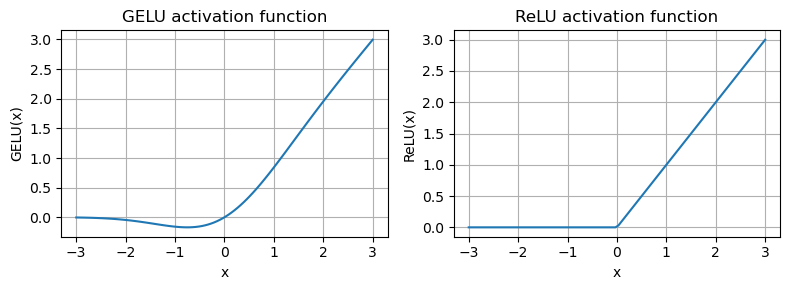

In [13]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# 샘플 데이터
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

- 모든 음수 값의 그래디언트를 0으로 만들지 않음

In [14]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [15]:
print(GPT_CONFIG_124M["emb_dim"])

768


In [16]:
ffn = FeedForward(GPT_CONFIG_124M)

# 입력 크기: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


## 4.4. 숏컷 연결 추가하기

- gradient가 한 개 이상의 층을 건너 뛰어 네트워크에 흐를 수 있도록 짧은 다른 경로를 만듦
- 이런 경로는 한 층의 출력을 이후 층의 출력에 더해서 만들어짐

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # 현재 층의 출력을 계산
            layer_output = layer(x)
            # 숏컷 연결을 적용할 수 있는지 확인
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # 정방향 계산
    output = model(x)
    target = torch.tensor([[0.]])

    # 타깃과 출력의 가까운 정도를 기반으로 손실을 계산
    loss = nn.MSELoss()
    loss = loss(output, target)

    # 그레이디언트를 계산하기 위한 역전파
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # 가중치의 그레이디언트의 평균 절댓값을 출력
            print(f"{name}의 평균 그레이디언트는 {param.grad.abs().mean().item()}입니다.")

숏컷 연결이 없을 때 그래디언트 값

In [18]:
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight의 평균 그레이디언트는 0.00020173590746708214입니다.
layers.1.0.weight의 평균 그레이디언트는 0.0001201116101583466입니다.
layers.2.0.weight의 평균 그레이디언트는 0.0007152042235247791입니다.
layers.3.0.weight의 평균 그레이디언트는 0.0013988739810883999입니다.
layers.4.0.weight의 평균 그레이디언트는 0.00504964729771018입니다.


숏컷 연결이 있을 때 그래디언트 값

In [19]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight의 평균 그레이디언트는 0.22169791162014008입니다.
layers.1.0.weight의 평균 그레이디언트는 0.20694102346897125입니다.
layers.2.0.weight의 평균 그레이디언트는 0.32896995544433594입니다.
layers.3.0.weight의 평균 그레이디언트는 0.2665732204914093입니다.
layers.4.0.weight의 평균 그레이디언트는 1.3258541822433472입니다.


- 숏컷 연결로 그래디언트 소실 문제를 막을 수 있음

## 4.5 어텐션과 선형 층을 트랜스포머 블록에 연결하기

In [20]:
!wget https://bit.ly/43BW1j3 -O previous_chapters.py

'wget'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [ ]:
from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # 어텐션 블록을 위한 숏컷 연결
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # 크기: [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # 원래 입력을 더함

        # 피드 포워드 블록을 위한 숏컷 연결
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # 원래 입력을 더함

        return x

In [24]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # 크기: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("입력 크기:", x.shape)
print("출력 크기:", output.shape)

입력 크기: torch.Size([2, 4, 768])
출력 크기: torch.Size([2, 4, 768])


## 4.6 GPT 모델 만들기

In [26]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # 크기 [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

- Transformer 블록을 GPT 구조에 연결
- Transformer 블록은 GPT-2 모델의 경우 12번 반복

In [27]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("입력 배치:\n", batch)
print("\n출력 크기:", out.shape)
print(out)

입력 배치:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

출력 크기: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [28]:
total_params = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 개수: {total_params:,}")

총 파라미터 개수: 163,009,536


- 파라미터 개수가 1억 2400만개가 아니라 1억 6300만개인 이유는 가중치 묶기를 적용했기 때문
- 토큰 임베딩 층의 가중치를 출력 층에 재사용
- 토큰 임베딩 층은 50257차원의 one-hot 인코딩된 입력 토큰을 768 차원의 임베딩 표현에 투영
- 출력 층은 768차원 임베딩을 단어로 변환하기 위해 50257차원 표현으로 다시 투영
- 따라서 임베딩 층과 출력 층의 파라미터 개수가 같음

In [29]:
print("토큰 임베딩 층의 가중치 크기:", model.tok_emb.weight.shape)
print("출력 층의 가중치 크기:", model.out_head.weight.shape)

토큰 임베딩 층의 가중치 크기: torch.Size([50257, 768])
출력 층의 가중치 크기: torch.Size([50257, 768])


In [30]:

total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"가중치 묶기를 고려한 훈련 가능한 파라미터 개수: {total_params_gpt2:,}")

가중치 묶기를 고려한 훈련 가능한 파라미터 개수: 124,412,160


모델에 필요한 메모리 크기

In [31]:
# 총 크기를 바이트 단위로 계산(float32라 가정하면 파라미터당 4바이트)
total_size_bytes = total_params * 4

# 메가바이트로 변환
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"모델에 필요한 메모리 공간: {total_size_mb:.2f} MB")

모델에 필요한 메모리 공간: 621.83 MB


## 4.7 텍스트 생성

- 그리디 디코딩에서는 각 단계마다 모델이 가장 높은 확률을 가진 단어(또는 토큰)을 다음 출력으로 선택

In [32]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx는 현재 문맥이 담긴 (batch, n_tokens) 크기의 인덱스 배열
    for _ in range(max_new_tokens):

        # 현재 문맥이 모델이 지원하는 문맥 크기를 초과하면 잘라냄
        idx_cond = idx[:, -context_size:]

        # 예측 생성
        with torch.no_grad():
            logits = model(idx_cond)

        # 마지막 타임 스텝만 사용
        # (batch, n_token, vocab_size) -> (batch, vocab_size)
        logits = logits[:, -1, :]

        # 확률을 얻기 위해 softmax 적용
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # 가장 높은 확률 값을 가진 항목의 인덱스를 얻음
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # 선택한 인덱스를 현재 시퀀스에 추가
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx


- generate_text_simple은 한 번에 하나의 토큰을 만드는 반복적인 과정 구현

In [34]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("인코딩된 ID:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

인코딩된 ID: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [35]:
model.eval() # 드롭아웃 끄기

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("출력:", out)
print("출력 길이:", len(out[0]))

출력: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
출력 길이: 10


- 텍스트로 다시 변환

In [36]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
